## Advanced Machine Learning – Project 1  
### Logistic Regression with FISTA and Unlabeled Data

This notebook presents the implementation and experimental analysis of logistic regression models developed for the project.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import time

from src.utils import *
from src.fista_logreg import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

### 1. Data Loading

In this section we load and inspect the datasets used in the experiments.

In [3]:
processed_datasets = {}

datasets = ["biodeg", "htru2", "magic", "spambase"]

for name in datasets:

    X, y = load_dataset(name)
    X, removed = prepare_dataset(X, threshold=0.9)
    y = y.loc[X.index]
    dataset_summary(X, y, name)
    if removed:
        print(f"Removed features due to high correlation: {removed}\n")

    processed_datasets[name] = {
        "X": X,
        "y": y,
    }

----------------------------------------
Dataset: biodeg
----------------------------------------
Number of samples: 1055
Number of features: 38

Target distribution:
Class
1    699
0    356
Name: count, dtype: int64


Removed features due to high correlation: ['V15', 'V27', 'V39']

----------------------------------------
Dataset: htru2
----------------------------------------
Number of samples: 17898
Number of features: 6

Target distribution:
class
0    16259
1     1639
Name: count, dtype: int64


Removed features due to high correlation: ['Profile_kurtosis', 'DM_kurtosis']

----------------------------------------
Dataset: magic
----------------------------------------
Number of samples: 19020
Number of features: 9

Target distribution:
class
1    12332
0     6688
Name: count, dtype: int64


Removed features due to high correlation: ['fConc1']

----------------------------------------
Dataset: spambase
----------------------------------------
Number of samples: 4601
Number of featu

During data loading, we perform early preprocessing:
- remove highly correlated features (correlation > 0.9)
- remove rows with missing values (applies only to the Higgs dataset a total of 9 rows removed, which has no impact on the experiments)

### 2. Logistic Regression with FISTA

In this section we compare our implementation of Logistic Lasso regression using the Fast Iterative Shrinkage-Thresholding Algorithm (FISTA) with sklearn implementation.

**Experiment 1 description**

In order to compare our implementation with the scikit-learn implementation we conduct an experiment - results of which are presented below.

For different values of max_iter, we train models using our FISTA-based implementation with a fixed regularization parameter λ = 1. For the sklearn baseline, we use an equivalent setting with C = 1/𝜆.

For the sklearn model, we use the following configuration:
LogisticRegression(l1_ratio=1, C=1/lam, solver='liblinear', fit_intercept=False, tol=1e-6, max_iter=max_iter, random_state=42).

Before training, all datasets are scaled using MinMax normalization and split into training and validation subsets.

For each configuration, we compute the ROC AUC score on the validation set and record the computation time, allowing us to compare both predictive performance and efficiency across methods.

In [4]:
def _print_progress(message):
    sys.stdout.write('\r' + message)
    sys.stdout.flush()


def compare_fista_sklearn(processed_datasets, max_iters=[100, 500, 1000], lam=1.0):
    """
    Compare FISTALogisticLasso with sklearn LogisticRegression (L1).

    Parameters
    ----------
    processed_datasets (dict): Dictionary of datasets with structure {name: {"X": X, "y": y}}
    max_iters (list of int): List of max_iter values to test for FISTA.
    lam (float): Regularization parameter for FISTA and sklearn (C = 1/lam).
    """
    results = []

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))

    for idx, (name, data) in enumerate(processed_datasets.items()):
        
        ax = axes.flatten()[idx]

        X, y = data["X"], data["y"]
        X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_valid = scaler.transform(X_valid)

        # --- FISTA ---
        fista_scores = []
        fista_times = []
        for max_iter in max_iters:
            _print_progress(f"             | dataset: {name} | FISTA                 ")
            _print_progress(f"max_iter={max_iter} ")
            model = FISTALogisticLasso(lam=lam, max_iter=max_iter, tol=1e-6)

            start = time.perf_counter()
            model.fit(X_train, y_train, auto_validate=False)
            end = time.perf_counter()
            elapsed = end - start

            y_proba = model.predict_proba(X_valid)
            score = roc_auc_score(y_valid, y_proba)
            
            fista_scores.append(score)
            fista_times.append(elapsed)

            results.append({
                "dataset": name,
                "method": "FISTA",
                "max_iter": max_iter,
                "AUC_ROC_score": score,
                "time": elapsed
            })

        # --- sklearn ---
        sklearn_scores = []
        sklearn_times = []
        for max_iter in max_iters:
            _print_progress(f"             | dataset: {name} | sklearn L1            ")
            _print_progress(f"max_iter={max_iter} ")
            clf = LogisticRegression(l1_ratio=1, C=1/lam, solver='liblinear', fit_intercept=False, tol=1e-6, max_iter=max_iter, random_state=42)

            start = time.perf_counter()
            clf.fit(X_train, y_train)
            end = time.perf_counter()
            elapsed = end - start

            y_proba = clf.predict_proba(X_valid)[:, 1]
            score = roc_auc_score(y_valid, y_proba)
            
            sklearn_scores.append(score)
            sklearn_times.append(elapsed)

            results.append({
                "dataset": name,
                "method": "sklearn L1",
                "max_iter": max_iter,
                "AUC_ROC_score": score,
                "time": elapsed
            })

        # --- plot ---
        ax_score = axes[0, idx]
        ax_time = axes[1, idx]

        all_scores = fista_scores + sklearn_scores
        center = (min(all_scores) + max(all_scores)) / 2

        ax_score.plot(max_iters, fista_scores, marker='o', label='FISTA', color="#FE6100")
        ax_score.plot(max_iters, sklearn_scores, marker='x', label='sklearn L1', color="#648FFF")
        ax_score.set_title(f"Dataset: {name}")
        ax_score.set_xlabel("max_iter")
        ax_score.set_ylabel("ROC-AUC")
        ax_score.set_ylim(center - 0.05, center + 0.05) 
        ax_score.grid(alpha=0.3)

        ax_time.plot(max_iters, fista_times, marker='o', label='FISTA', color="#FE6100", linestyle="dashed")
        ax_time.plot(max_iters, sklearn_times, marker='x', label='sklearn L1', color="#648FFF", linestyle="dashed")

        ax_time.set_ylabel("Time (s)")
        ax_time.set_yscale('log')
        ax_time.set_xlabel("max_iter")
        ax_time.grid(alpha=0.3)
        
    sys.stdout.write('\r' + ' ' * 100 + '\r')
    sys.stdout.flush()

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
    handles,
        labels,
        loc='lower center',
        ncol=3,
        bbox_to_anchor=(0.5, -0.02),
        frameon=False
    )

    plt.suptitle("Comparison of Custom FISTA Implementation with Scikit-learn", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
    plt.show()

    df = pd.DataFrame(results)
    df.to_csv("results/fista_compare_sklearn.csv", index=False)

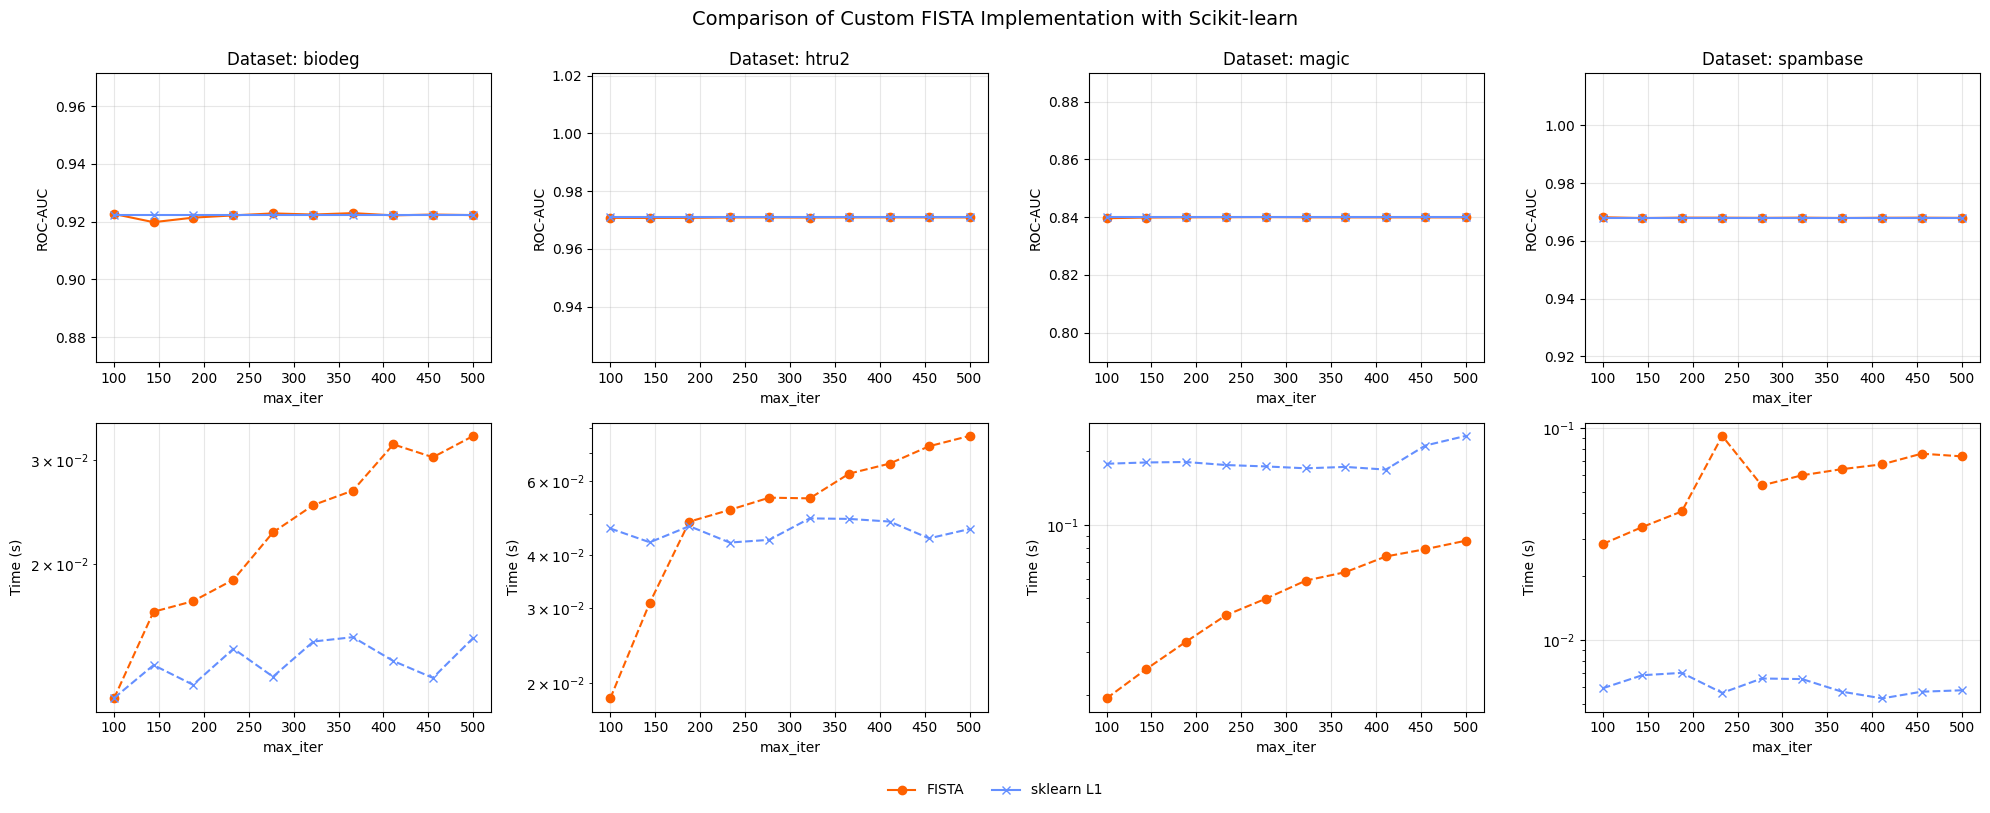

In [5]:
compare_fista_sklearn(processed_datasets, max_iters=np.linspace(100, 500, 10).astype(int), lam=1.0)

**Experiment 2 Description**

In [6]:
def compare_fista_validation(
    processed_datasets,
    measures=("f1", "precision", "recall", "roc_auc", "pr_auc", "balanced_accuracy"),
    lambda_values=np.logspace(-5, 1, 30),
    max_iter=500
):
    results = []

    n_datasets = len(processed_datasets)
    n_measures = len(measures)

    fig, axes = plt.subplots(n_measures, n_datasets, figsize=(4*n_datasets, 3*n_measures))

    if n_measures == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_datasets == 1:
        axes = np.expand_dims(axes, axis=1)

    for col_idx, (name, data) in enumerate(processed_datasets.items()):

        X, y = data["X"], data["y"]

        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_valid = scaler.transform(X_valid)

        for row_idx, measure in enumerate(measures):

            model = FISTALogisticLasso(
                lambda_values=lambda_values,
                max_iter=max_iter
            )

            model.fit(
                X_train,
                y_train,
                auto_validate=True,
                X_valid=X_valid,
                y_valid=y_valid,
                measure=measure
            )

            for lam, score in zip(model.lambda_values, model.scores_):
                results.append({
                    "dataset": name,
                    "measure": measure,
                    "lambda": lam,
                    "score": score,
                    "best_lambda": model.best_lambda_,
                })

            ax = axes[row_idx, col_idx]

            ax.plot(
                model.lambda_values,
                model.scores_,
                linewidth=1
            )

            ax.axvline(
                model.best_lambda_,
                linestyle="--",
                linewidth=1
            )

            ax.set_xscale("log")
            ax.set_title(f"{name}")
            
            if col_idx == 0:
                ax.set_ylabel(measure)

            if row_idx == n_measures - 1:
                ax.set_xlabel("lambda")

            ax.grid(alpha=0.3)


    plt.suptitle("FISTA lambda validation paths", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.grid(alpha=0.3)
    plt.show()

    df = pd.DataFrame(results)
    df.to_csv("results/fista_validation_results.csv", index=False)

    return df

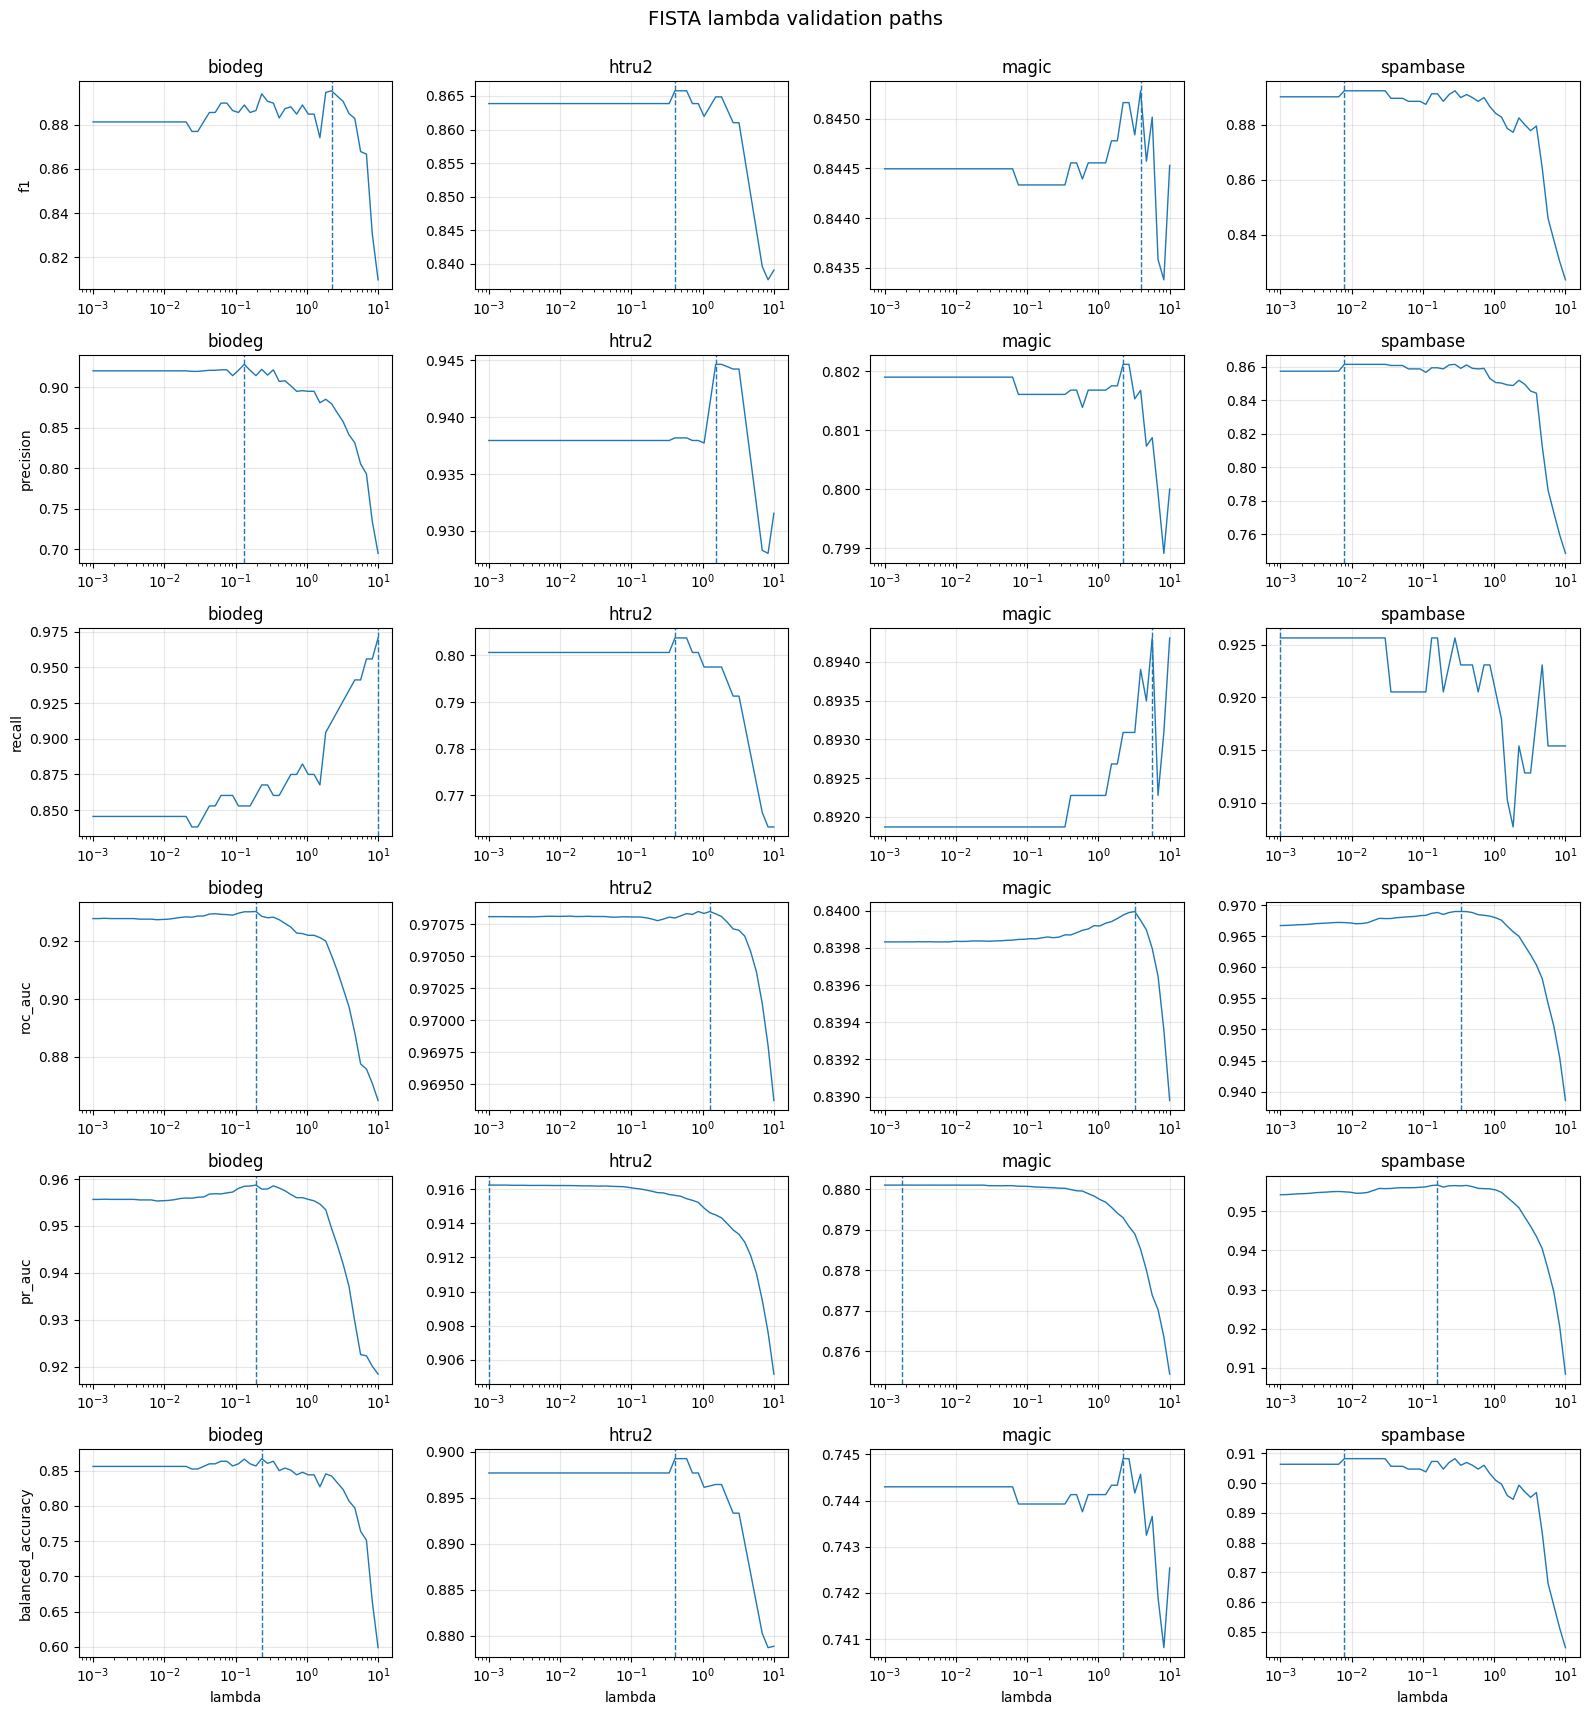

In [7]:
df = compare_fista_validation(
    processed_datasets,
    measures=("f1", "precision", "recall", "roc_auc", "pr_auc", "balanced_accuracy"),
    lambda_values=np.logspace(-3, 1, 50),
    max_iter=500
)

**Experiment 3 Description**

In [26]:
def compare_validation_strategies(
    processed_datasets,
    measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
    lambda_values=np.logspace(-5, 1, 30),
    n_repeats=10,
    test_metric="roc_auc",
    max_iter=500,
    random_state=42
):
    results = []

    for dataset_name, data in processed_datasets.items():

        X, y = data["X"], data["y"]

        for repeat in range(n_repeats):

            X_train, X_temp, y_train, y_temp = train_test_split(
                X, y, test_size=0.4, random_state=random_state + repeat
            )

            X_valid, X_test, y_valid, y_test = train_test_split(
                X_temp, y_temp, test_size=0.5, random_state=random_state + repeat
            )

            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_valid = scaler.transform(X_valid)
            X_test = scaler.transform(X_test)

            for measure in measures:

                model = FISTALogisticLasso(
                    lambda_values=lambda_values,
                    max_iter=max_iter
                )

                model.fit(
                    X_train,
                    y_train,
                    auto_validate=True,
                    X_valid=X_valid,
                    y_valid=y_valid,
                    measure=measure
                )

                proba = model.predict_proba(X_test)

                if test_metric == "roc_auc":
                    score = roc_auc_score(y_test, proba)

                elif test_metric == "pr_auc":
                    score = average_precision_score(y_test, proba)

                else:
                    y_pred = (proba >= 0.5).astype(int)

                    if test_metric == "f1":
                        score = f1_score(y_test, y_pred)
                    elif test_metric == "balanced_accuracy":
                        score = balanced_accuracy_score(y_test, y_pred)
                    else:
                        raise ValueError("Unsupported test metric")

                results.append({
                    "dataset": dataset_name,
                    "measure": measure,
                    "test_score": score,
                    "best_lambda": model.best_lambda_,
                    "repeat": repeat
                })
    
    df = pd.DataFrame(results)
    df.to_csv("results/diff_metrics.csv", index=False)

    return df

def plot_boxplot(
        df,
        measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
        test_metric="roc_auc"
        ):

    datasets = df["dataset"].unique()
    n_datasets = len(datasets)

    n_cols = 2
    n_rows = int(np.ceil(n_datasets / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    axes = np.atleast_1d(axes).flatten()

    colors = {
        "f1": "#648FFF",
        "precision": "#785EF0",
        "recall": "#DC267F",
        "balanced_accuracy": "#FE6100",
        "roc_auc": "#FFB000",
        "pr_auc": "#2FBF71"
    }

    for idx, dataset_name in enumerate(datasets):

        ax = axes[idx]
        subset = df[df["dataset"] == dataset_name]

        data_to_plot = [
            subset[subset["measure"] == m]["test_score"]
            for m in measures
        ]

        box = ax.boxplot(
            data_to_plot,
            patch_artist=True,
            tick_labels=measures
        )
        for median in box["medians"]:
            median.set_color("black")
            median.set_linewidth(1)

        for patch, measure in zip(box["boxes"], measures):
            patch.set_facecolor(colors.get(measure, "gray"))
            patch.set_alpha(0.6)

        ax.set_title(dataset_name)
        ax.set_ylabel(test_metric)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=30)

    for j in range(len(datasets), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Comparison of validation metrics (test metric: {test_metric})", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

In [17]:
df = compare_validation_strategies(
    processed_datasets,
    measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
    lambda_values=np.logspace(-5, 1, 30),
    n_repeats=10,
    test_metric="roc_auc",
    max_iter=500,
    random_state=42
)

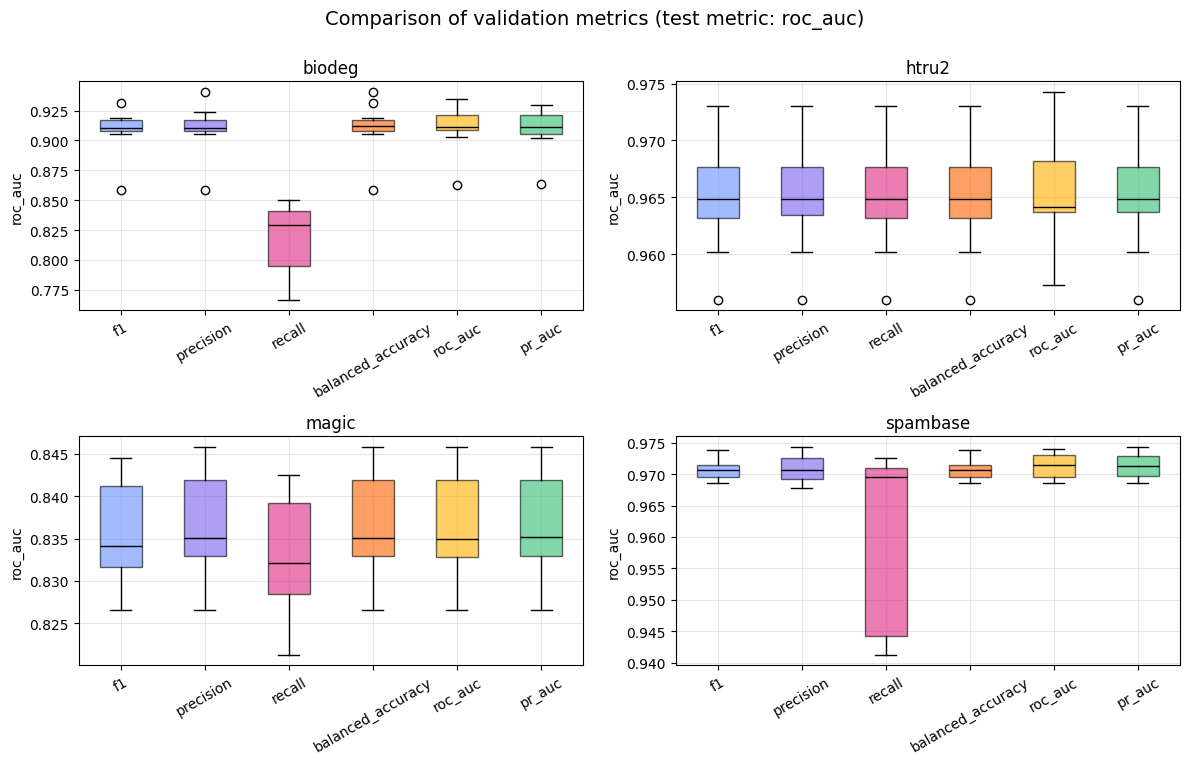

In [27]:
plot_boxplot(df, measures=("f1", "precision", "recall", "balanced_accuracy", "roc_auc", "pr_auc"),
             test_metric="roc_auc")